# Legal AI Document Intelligence & Classification


## Project Overview
**Goal:** classify legal clauses into one of **100 legal document categories** using the LEDGAR dataset from LexGLUE.

This notebook reproduces the project workflow: data analysis, TF-IDF baselines, Random Forest, XGBoost, a PyTorch neural network, BERT, RoBERTa, T5, error analysis, and Random Forest explainability.

### Recorded results
| Model | Accuracy | Macro F1 | Weighted F1 |
|---|---:|---:|---:|
| TF-IDF + Random Forest | 86.15% | 78.74% | 85.37% |
| TF-IDF + Logistic Regression | 83.28% | 77.10% | 83.79% |
| TF-IDF + XGBoost | 81.20% | 72.79% | 80.39% |
| PyTorch Neural Network | 79.03% | 71.25% | 79.52% |
| T5 | 76.10% | 62.43% | 74.46% |
| RoBERTa | 70.45% | 46.07% | 63.68% |
| BERT | 64.25% | 36.09% | 54.83% |

**Run All:** expensive models are cached to disk when saved artifacts exist.

# Download data

In [5]:
from datasets import load_dataset

dataset = load_dataset(
    "coastalcph/lex_glue",
    "ledgar"
)

In [6]:
print(dataset)

for split in dataset:
    print(split, len(dataset[split]))

print(dataset["train"].features)

print(dataset["train"][0])

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 60000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 10000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 10000
    })
})
train 60000
test 10000
validation 10000
{'text': Value('string'), 'label': ClassLabel(names=['Adjustments', 'Agreements', 'Amendments', 'Anti-Corruption Laws', 'Applicable Laws', 'Approvals', 'Arbitration', 'Assignments', 'Assigns', 'Authority', 'Authorizations', 'Base Salary', 'Benefits', 'Binding Effects', 'Books', 'Brokers', 'Capitalization', 'Change In Control', 'Closings', 'Compliance With Laws', 'Confidentiality', 'Consent To Jurisdiction', 'Consents', 'Construction', 'Cooperation', 'Costs', 'Counterparts', 'Death', 'Defined Terms', 'Definitions', 'Disability', 'Disclosures', 'Duties', 'Effective Dates', 'Effectiveness', 'Employment', 'Enforceability', 'Enforcements', 'Entire Agreements', 'Erisa',

## Dataset analysis

Before we build any models, we need to understand whether the data is balanced and how long the legal clauses are.

In [ ]:
from collections import Counter
import numpy as np

train = dataset["train"]
validation = dataset["validation"]
test = dataset["test"]

# 1. Number of classes
label_names = train.features["label"].names

print("Number of classes:", len(label_names))


# 2. Class distribution
label_counts = Counter(train["label"])

print("\nMost common classes:")
for label_id, count in label_counts.most_common(10):
    print(f"{label_names[label_id]}: {count}")

print("\nLeast common classes:")
for label_id, count in label_counts.most_common()[-10:]:
    print(f"{label_names[label_id]}: {count}")


# 3. Document length
lengths = np.array([
    len(text.split())
    for text in train["text"]
])

print("\nDocument length statistics:")
print("Mean:", round(lengths.mean(), 2))
print("Median:", np.median(lengths))
print("Minimum:", lengths.min())
print("Maximum:", lengths.max())
print("95th percentile:", np.percentile(lengths, 95))


# 4. Missing / empty text
empty_text = sum(
    1 for text in train["text"]
    if text is None or not text.strip()
)

print("\nEmpty documents:", empty_text)


# 5. Duplicate documents
unique_texts = len(set(train["text"]))
duplicate_count = len(train) - unique_texts

print("Duplicate documents:", duplicate_count)

Number of classes: 100

Most common classes:
Governing Laws: 3167
Notices: 2493
Counterparts: 2427
Entire Agreements: 2340
Severability: 1808
Survival: 1469
Amendments: 1467
Assignments: 1327
Expenses: 1224
Terms: 1166

Least common classes:
Approvals: 178
Consent To Jurisdiction: 175
Costs: 168
Venues: 131
Powers: 125
Sanctions: 118
Anti-Corruption Laws: 106
Qualifications: 47
Assigns: 31
Books: 23

Document length statistics:
Mean: 113.9
Median: 86.0
Minimum: 3
Maximum: 1215
95th percentile: 305.0

Empty documents: 0
Duplicate documents: 0


Visualize the data

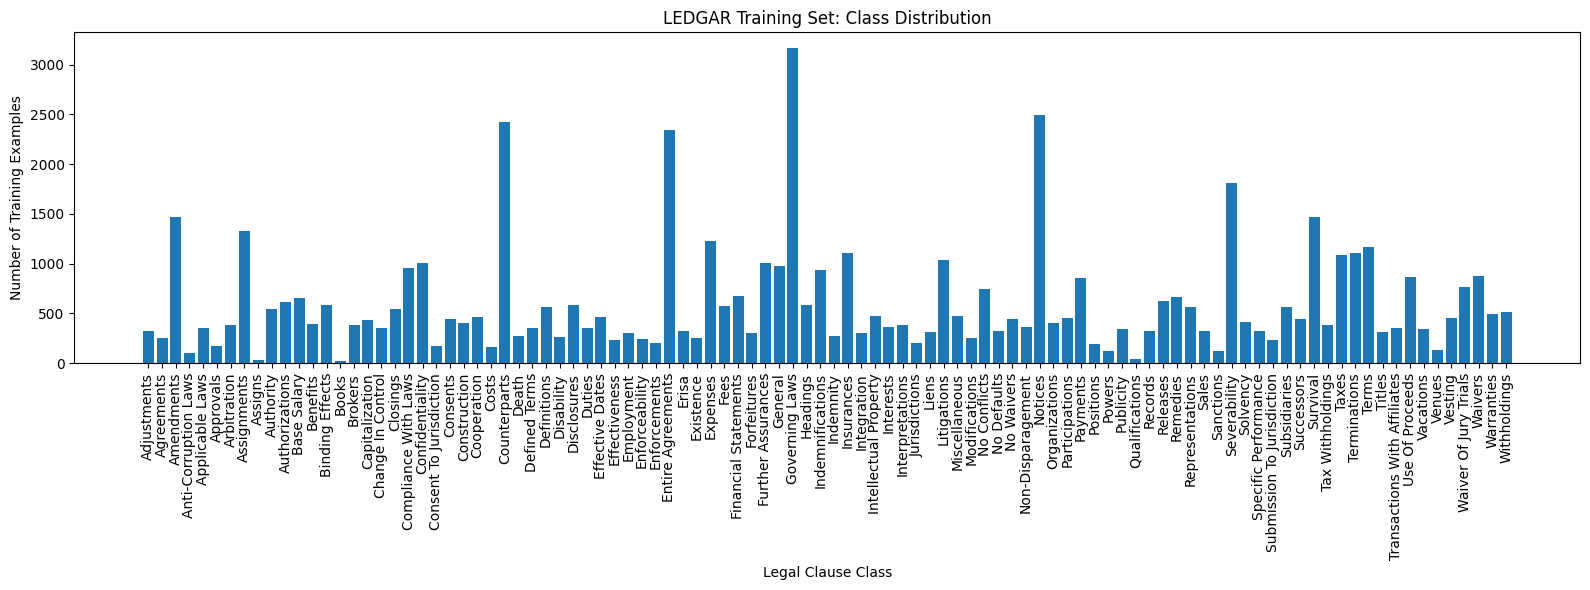

In [ ]:
import matplotlib.pyplot as plt

# Plot 1: Class distribution
class_counts = [
    label_counts[i]
    for i in range(len(label_names))
]

plt.figure(figsize=(16, 6))

plt.bar(
    range(len(label_names)),
    class_counts
)

plt.xlabel("Legal Clause Class")
plt.ylabel("Number of Training Examples")
plt.title("LEDGAR Training Set: Class Distribution")

plt.xticks(
    range(len(label_names)),
    label_names,
    rotation=90
)

plt.tight_layout()
plt.show()

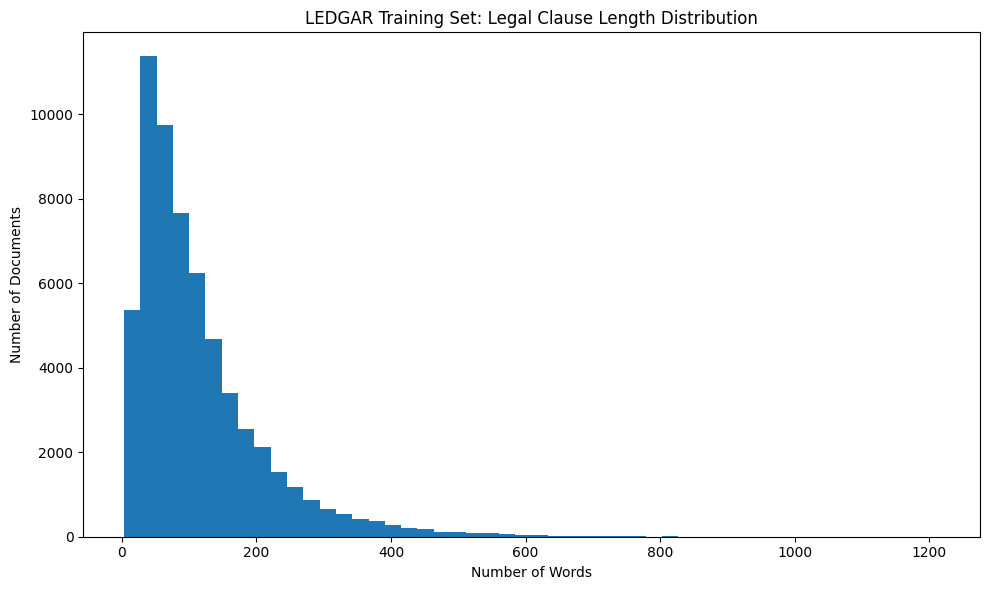

In [ ]:
# Plot 2: Document length
plt.figure(figsize=(10, 6))

plt.hist(
    lengths,
    bins=50
)

plt.xlabel("Number of Words")
plt.ylabel("Number of Documents")
plt.title("LEDGAR Training Set: Legal Clause Length Distribution")

plt.tight_layout()
plt.show()

In [10]:
largest_class = max(label_counts.values())
smallest_class = min(label_counts.values())

imbalance_ratio = largest_class / smallest_class

print("Largest class:", largest_class)
print("Smallest class:", smallest_class)
print("Imbalance ratio:", round(imbalance_ratio, 2))

Largest class: 3167
Smallest class: 23
Imbalance ratio: 137.7


# TF-IDF Logistic regression

## Get the dataset

In [ ]:
import time
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [12]:
train = dataset["train"]
validation = dataset["validation"]
test = dataset["test"]

X_train = train["text"]
y_train = train["label"]

X_validation = validation["text"]
y_validation = validation["label"]

X_test = test["text"]
y_test = test["label"]

print("Training examples:", len(X_train))
print("Validation examples:", len(X_validation))
print("Test examples:", len(X_test))

Training examples: 60000
Validation examples: 10000
Test examples: 10000


In [13]:
# Step 2 — Convert text into TF-IDF
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

start_time = time.time()

X_train_tfidf = tfidf.fit_transform(X_train)

X_validation_tfidf = tfidf.transform(X_validation)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF training shape:", X_train_tfidf.shape)
print("TF-IDF validation shape:", X_validation_tfidf.shape)
print("TF-IDF test shape:", X_test_tfidf.shape)

print("TF-IDF vocabulary size:", len(tfidf.vocabulary_))
print("Transformation time:", round(time.time() - start_time, 2), "seconds")

TF-IDF training shape: (60000, 210328)
TF-IDF validation shape: (10000, 210328)
TF-IDF test shape: (10000, 210328)
TF-IDF vocabulary size: 210328
Transformation time: 4.0 seconds


We fit TF-IDF only on the training data so information from validation/test doesn't leak into training.

## Train Logistic Regression

Because we have 100 classes and significant imbalance, we'll use class weighting:

In [ ]:
# Takes 30 minute to run 
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    solver="saga",
    n_jobs=-1
)

start_time = time.time()

model.fit(X_train_tfidf, y_train)

training_time = time.time() - start_time

print("Training completed.")
print("Training time:", round(training_time, 2), "seconds")

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


This took a little while because it trained on 60,000 documents × potentially thousands of TF-IDF features across 100 classes.

In [20]:
tfidf_fast = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
    max_features=10000,
    sublinear_tf=True
)

X_train_tfidf_fast = tfidf_fast.fit_transform(X_train)
X_validation_tfidf_fast = tfidf_fast.transform(X_validation)

print(X_train_tfidf_fast.shape)

(60000, 10000)


In [21]:
model = LogisticRegression(
    max_iter=300,
    class_weight="balanced",
    solver="saga",
    random_state=42,
    n_jobs=-1
)

start_time = time.time()

model.fit(
    X_train_tfidf_fast,
    y_train
)

training_time = time.time() - start_time

print("Training completed.")
print("Training time:", round(training_time, 2), "seconds")

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Training completed.
Training time: 140.47 seconds


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [23]:
import joblib

joblib.dump(
    model,
    "logistic_regression_model.joblib"
)

joblib.dump(
    tfidf_fast,
    "tfidf_vectorizer.joblib"
)

print("Model and vectorizer saved.")

Model and vectorizer saved.


## Evaluate on validation data: erroe

In [ ]:
start_time = time.time()

y_pred = model.predict(X_validation_tfidf)

prediction_time = time.time() - start_time

accuracy = accuracy_score(y_validation, y_pred)

macro_f1 = f1_score(
    y_validation,
    y_pred,
    average="macro"
)

weighted_f1 = f1_score(
    y_validation,
    y_pred,
    average="weighted"
)

print("Validation Results")
print("------------------")
print("Accuracy:", round(accuracy, 4))
print("Macro F1:", round(macro_f1, 4))
print("Weighted F1:", round(weighted_f1, 4))
print("Prediction time:", round(prediction_time, 2), "seconds")

Why 3 metrics?

1. Accuracy: What percentage of all predictions were correct?

2. Macro F1: Calculates F1 separately for each of the 100 classes and gives every class equal weight.

3. Weighted F1: Gives more influence to classes with more examples. <-  This is our primary metric

This lets us see whether the model performs well overall while also seeing what happens when rare classes receive equal importance.

## Look at individual class performance

In [ ]:
report = classification_report(
    y_validation,
    y_pred,
    target_names=label_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()

report_df.sort_values(
    "f1-score",
    ascending=False
).head(10)

# We want to investigate: "Which types of legal clauses does the model understand well, and which ones does it struggle to distinguish?"

,precision,recall,f1-score,support
Transactions With Affiliates,1.000000,0.986842,0.993377,76.0
Vacations,0.981481,1.000000,0.990654,53.0
Base Salary,0.982609,0.991228,0.986900,114.0
Counterparts,0.981395,0.983683,0.982538,429.0
Solvency,0.972973,0.986301,0.979592,73.0
Financial Statements,0.970297,0.980000,0.975124,100.0
Waiver Of Jury Trials,0.972603,0.972603,0.972603,146.0
Insurances,0.952607,0.985294,0.968675,204.0
Erisa,0.964912,0.964912,0.964912,57.0
Non-Disparagement,0.947368,0.981818,0.964286,55.0


In [ ]:
# 10 worst-performing classes
report_df.sort_values(
    "f1-score",
    ascending=True
).head(10)

,precision,recall,f1-score,support
Assigns,0.000000,0.000000,0.000000,3.0
Books,0.000000,0.000000,0.000000,0.0
Applicable Laws,0.245098,0.362319,0.292398,69.0
Qualifications,0.250000,0.375000,0.300000,8.0
Jurisdictions,0.341463,0.424242,0.378378,33.0
Venues,0.288889,0.684211,0.406250,19.0
General,0.590000,0.393333,0.472000,150.0
Powers,0.600000,0.400000,0.480000,15.0
Enforcements,0.583333,0.456522,0.512195,46.0
Indemnity,0.553191,0.553191,0.553191,47.0


In [ ]:
# Overall baseline metrics
print("Baseline Validation Results")
print("---------------------------")

print("Accuracy:", round(accuracy, 4))
print("Macro F1:", round(macro_f1, 4))
print("Weighted F1:", round(weighted_f1, 4))

Baseline Validation Results
---------------------------
Accuracy: 0.8388
Macro F1: 0.7746
Weighted F1: 0.8404


In [ ]:
# Biggest classification errors
cm = confusion_matrix(
    y_validation,
    y_pred
)

# Remove correct predictions from the diagonal
cm_errors = cm.copy()
np.fill_diagonal(cm_errors, 0)

# Find the 20 largest errors
error_pairs = []

for true_class in range(len(label_names)):
    for predicted_class in range(len(label_names)):
        count = cm_errors[true_class, predicted_class]

        if count > 0:
            error_pairs.append(
                (
                    count,
                    label_names[true_class],
                    label_names[predicted_class]
                )
            )

error_pairs = sorted(
    error_pairs,
    reverse=True
)

for count, true_label, predicted_label in error_pairs[:20]:
    print(
        f"{count:4d} | True: {true_label} "
        f"→ Predicted: {predicted_label}"
    )

  72 | True: Governing Laws → Predicted: Applicable Laws
  35 | True: Applicable Laws → Predicted: Governing Laws
  27 | True: Amendments → Predicted: Modifications
  21 | True: Withholdings → Predicted: Tax Withholdings
  21 | True: Survival → Predicted: Warranties
  19 | True: Authorizations → Predicted: Authority
  17 | True: Tax Withholdings → Predicted: Withholdings
  17 | True: Successors → Predicted: Binding Effects
  17 | True: Indemnifications → Predicted: Indemnity
  17 | True: Definitions → Predicted: Defined Terms
  15 | True: Taxes → Predicted: Withholdings
  15 | True: Taxes → Predicted: Tax Withholdings
  15 | True: Governing Laws → Predicted: Venues
  15 | True: Binding Effects → Predicted: Enforceability
  14 | True: Waivers → Predicted: No Waivers
  14 | True: Defined Terms → Predicted: Definitions
  13 | True: No Waivers → Predicted: Waivers
  13 | True: Governing Laws → Predicted: Jurisdictions
  12 | True: Warranties → Predicted: Representations
  12 | True: Terms 

Your Logistic Regression baseline Metric Score
1. Accuracy: 83.28%
2. Macro F1: 	77.10%
3. Weighted F1:	83.79%

The difference between weighted F1 (0.838) and macro F1 (0.771) confirms that the model performs much better on common classes than rare/difficult classes.

# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

start_time = time.time()

rf_model.fit(
    X_train_tfidf,
    y_train
)

rf_training_time = time.time() - start_time

print("Random Forest training completed.")
print("Training time:", round(rf_training_time, 2), "seconds")

Random Forest training completed.
Training time: 162.7 seconds


In [ ]:
# Make predictions
start_time = time.time()

y_pred_rf = rf_model.predict(X_validation_tfidf)

rf_prediction_time = time.time() - start_time

print("Prediction time:", round(rf_prediction_time, 2), "seconds")

Prediction time: 3.21 seconds


In [ ]:
# Calculate metrics
accuracy_rf = accuracy_score(
    y_validation,
    y_pred_rf
)

macro_f1_rf = f1_score(
    y_validation,
    y_pred_rf,
    average="macro"
)

weighted_f1_rf = f1_score(
    y_validation,
    y_pred_rf,
    average="weighted"
)

print("Random Forest Validation Results")
print("---------------------------------")
print("Accuracy:", round(accuracy_rf, 4))
print("Macro F1:", round(macro_f1_rf, 4))
print("Weighted F1:", round(weighted_f1_rf, 4))

Random Forest Validation Results
---------------------------------
Accuracy: 0.8615
Macro F1: 0.7874
Weighted F1: 0.8537


In [ ]:
# Compare with Logistic Regression
comparison = pd.DataFrame({
    "Model": [
        "TF-IDF + Logistic Regression",
        "TF-IDF + Random Forest"
    ],
    "Accuracy": [
        accuracy,
        accuracy_rf
    ],
    "Macro F1": [
        macro_f1,
        macro_f1_rf
    ],
    "Weighted F1": [
        weighted_f1,
        weighted_f1_rf
    ],
    "Training Time (sec)": [
        training_time,
        rf_training_time
    ]
})

comparison

,Model,Accuracy,Macro F1,Weighted F1,Training Time (sec)
0,TF-IDF + Logistic Regression,0.8388,0.774571,0.840426,2936.906747
1,TF-IDF + Random Forest,0.8615,0.787371,0.853693,551.075257


In [ ]:
# Which classes Random Forest improved or struggled with.
rf_report = classification_report(
    y_validation,
    y_pred_rf,
    target_names=label_names,
    output_dict=True,
    zero_division=0
)

rf_report_df = pd.DataFrame(rf_report).transpose()

rf_report_df.sort_values(
    "f1-score",
    ascending=True
).head(10)

,precision,recall,f1-score,support
Assigns,0.000000,0.000000,0.000000,3.0
Books,0.000000,0.000000,0.000000,0.0
Applicable Laws,0.800000,0.115942,0.202532,69.0
Qualifications,1.000000,0.250000,0.400000,8.0
Powers,1.000000,0.266667,0.421053,15.0
Venues,0.666667,0.315789,0.428571,19.0
Miscellaneous,0.916667,0.328358,0.483516,67.0
Enforcements,1.000000,0.369565,0.539683,46.0
Jurisdictions,0.866667,0.393939,0.541667,33.0
Costs,0.900000,0.409091,0.562500,22.0


In [ ]:
rf_report_df.sort_values(
    "f1-score",
    ascending=False
).head(10)

,precision,recall,f1-score,support
Base Salary,0.991304,1.000000,0.995633,114.0
Transactions With Affiliates,1.000000,0.973684,0.986667,76.0
Counterparts,0.955257,0.995338,0.974886,429.0
Erisa,0.965517,0.982456,0.973913,57.0
Waiver Of Jury Trials,0.948052,1.000000,0.973333,146.0
Non-Disparagement,0.981481,0.963636,0.972477,55.0
Brokers,0.970588,0.970588,0.970588,68.0
Participations,0.987179,0.950617,0.968553,81.0
Closings,0.974359,0.950000,0.962025,80.0
Insurances,0.935185,0.990196,0.961905,204.0


In [ ]:
classes_to_check = [
    "Applicable Laws",
    "Powers",
    "Venues",
    "General",
    "Jurisdictions",
    "Enforcements",
    "Agreements",
    "Assigns",
    "Qualifications",
    "Books"
]

comparison_classes = pd.DataFrame({
    "Logistic Regression F1": report_df.loc[
        classes_to_check, "f1-score"
    ],
    "Random Forest F1": rf_report_df.loc[
        classes_to_check, "f1-score"
    ]
})

comparison_classes["Change"] = (
    comparison_classes["Random Forest F1"]
    - comparison_classes["Logistic Regression F1"]
)

comparison_classes.sort_values(
    "Change",
    ascending=False
)

,Logistic Regression F1,Random Forest F1,Change
General,0.472000,0.666667,0.194667
Jurisdictions,0.378378,0.541667,0.163288
Qualifications,0.300000,0.400000,0.100000
Agreements,0.571429,0.647059,0.075630
Enforcements,0.512195,0.539683,0.027487
Venues,0.406250,0.428571,0.022321
Assigns,0.000000,0.000000,0.000000
Books,0.000000,0.000000,0.000000
Powers,0.480000,0.421053,-0.058947
Applicable Laws,0.292398,0.202532,-0.089866


This confirms that Random Forest improved overall performance, but it did not solve the rare-class problem.

Random Forest is better overall, but model performance is still highly uneven across legal categories. In particular, extremely rare classes remain difficult.

And Applicable Laws got worse, despite Random Forest having higher overall Macro F1.

# XGBoost

In [ ]:
y_train_xgb = np.array(y_train)
y_validation_xgb = np.array(y_validation)

print("X_train:", X_train_xgb_small.shape)
print("y_train:", y_train_xgb.shape)
print("X_validation:", X_validation_xgb_small.shape)
print("y_validation:", y_validation_xgb.shape)

In [14]:
from xgboost import XGBClassifier

xgb_tfidf_small = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=5,
    max_features=3000,
    sublinear_tf=True
)

X_train_xgb_small = xgb_tfidf_small.fit_transform(X_train)
X_validation_xgb_small = xgb_tfidf_small.transform(X_validation)

print(X_train_xgb_small.shape)

(60000, 3000)


In [ ]:
xgb_model = XGBClassifier(
    n_estimators=50,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=len(label_names),
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

start_time = time.time()

xgb_model.fit(
    X_train_xgb_small,
    y_train_xgb
)

xgb_training_time = time.time() - start_time

print("XGBoost training completed.")
print("Training time:", round(xgb_training_time, 2), "seconds")

In [ ]:
# Evaluate XGBoost
y_pred_xgb = xgb_model.predict(
    X_validation_xgb_small
)

accuracy_xgb = accuracy_score(
    y_validation_xgb,
    y_pred_xgb
)

macro_f1_xgb = f1_score(
    y_validation_xgb,
    y_pred_xgb,
    average="macro"
)

weighted_f1_xgb = f1_score(
    y_validation_xgb,
    y_pred_xgb,
    average="weighted"
)

print("XGBoost Validation Results")
print("--------------------------")
print("Accuracy:", round(accuracy_xgb, 4))
print("Macro F1:", round(macro_f1_xgb, 4))
print("Weighted F1:", round(weighted_f1_xgb, 4))

XGBoost Validation Results
--------------------------
Accuracy: 0.812
Macro F1: 0.7279
Weighted F1: 0.8039


In [ ]:
# Add XGBoost results to your model comparison
comparison = pd.DataFrame({
    "Model": [
        "TF-IDF + Logistic Regression",
        "TF-IDF + Random Forest",
        "TF-IDF + XGBoost"
    ],
    "Accuracy": [
        accuracy,
        accuracy_rf,
        accuracy_xgb
    ],
    "Macro F1": [
        macro_f1,
        macro_f1_rf,
        macro_f1_xgb
    ],
    "Weighted F1": [
        weighted_f1,
        weighted_f1_rf,
        weighted_f1_xgb
    ],
    "Training Time (sec)": [
        training_time,
        rf_training_time,
        xgb_training_time
    ]
})

comparison

,Model,Accuracy,Macro F1,Weighted F1,Training Time (sec)
0,TF-IDF + Logistic Regression,0.8388,0.774571,0.840426,2936.906747
1,TF-IDF + Random Forest,0.8615,0.787371,0.853693,551.075257
2,TF-IDF + XGBoost,0.8120,0.727908,0.803928,161.421942


The experiment demonstrated that:
- Random Forest performed best overall.
- Logistic Regression was competitive despite being much simpler.
- XGBoost with the constrained 3,000-feature representation performed worse.

The XGBoost experiment was also substantially more computationally expensive than we'd like.

The classical models are struggling particularly with semantically similar legal categories.

# PyTorch

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [14]:
torch_tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=5,
    max_features=1000,
    sublinear_tf=True
)

X_train_torch = torch_tfidf.fit_transform(X_train)
X_validation_torch = torch_tfidf.transform(X_validation)

print("Training shape:", X_train_torch.shape)
print("Validation shape:", X_validation_torch.shape)

Training shape: (60000, 1000)
Validation shape: (10000, 1000)


In [15]:
X_train_tensor = torch.tensor(
    X_train_torch.toarray(),
    dtype=torch.float32
)

X_validation_tensor = torch.tensor(
    X_validation_torch.toarray(),
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    np.array(y_train),
    dtype=torch.long
)

y_validation_tensor = torch.tensor(
    np.array(y_validation),
    dtype=torch.long
)

print("Training tensor:", X_train_tensor.shape)
print("Validation tensor:", X_validation_tensor.shape)

Training tensor: torch.Size([60000, 1000])
Validation tensor: torch.Size([10000, 1000])


In [16]:
# Create DataLoaders
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

validation_dataset = TensorDataset(
    X_validation_tensor,
    y_validation_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=256,
    shuffle=False
)

In [17]:
# Build the PyTorch neural network
class LegalDocumentNN(nn.Module):

    def __init__(self, input_size, num_classes):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.network(x)

In [18]:
# Create model
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

pytorch_model = LegalDocumentNN(
    input_size=1000,
    num_classes=len(label_names)
).to(device)

print(pytorch_model)


Using device: cpu
LegalDocumentNN(
  (network): Sequential(
    (0): Linear(in_features=1000, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=256, out_features=100, bias=True)
  )
)


In [19]:
# Loss and optimizer
class_counts = np.bincount(
    np.array(y_train),
    minlength=len(label_names)
)

class_weights = len(y_train) / (
    len(label_names) * class_counts
)

class_weights[class_counts == 0] = 0

class_weights_tensor = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor
)

optimizer = torch.optim.Adam(
    pytorch_model.parameters(),
    lr=0.001
)

print("Loss function and optimizer ready.")


Loss function and optimizer ready.


In [ ]:
# Train
num_epochs = 5

for epoch in range(num_epochs):

    pytorch_model.train()

    total_loss = 0

    start_time = time.time()

    for batch_number, (X_batch, y_batch) in enumerate(train_loader):

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = pytorch_model(X_batch)

        loss = criterion(
            outputs,
            y_batch
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        # Show progress every 100 batches
        if (batch_number + 1) % 100 == 0:
            print(
                f"Epoch {epoch + 1}/{num_epochs} | "
                f"Batch {batch_number + 1}/{len(train_loader)} | "
                f"Loss: {loss.item():.4f}"
            )

    epoch_time = time.time() - start_time

    average_loss = total_loss / len(train_loader)

    print(
        f"\nEpoch {epoch + 1} completed | "
        f"Average Loss: {average_loss:.4f} | "
        f"Time: {epoch_time:.1f}s\n"
    )

Epoch 1/5 | Batch 100/469 | Loss: 2.8622
Epoch 1/5 | Batch 200/469 | Loss: 1.8655
Epoch 1/5 | Batch 300/469 | Loss: 1.0562
Epoch 1/5 | Batch 400/469 | Loss: 1.1383

Epoch 1 completed | Average Loss: 2.1375 | Time: 1.3s

Epoch 2/5 | Batch 100/469 | Loss: 1.2837
Epoch 2/5 | Batch 200/469 | Loss: 0.8131
Epoch 2/5 | Batch 300/469 | Loss: 1.0917
Epoch 2/5 | Batch 400/469 | Loss: 0.8416

Epoch 2 completed | Average Loss: 1.0604 | Time: 1.1s

Epoch 3/5 | Batch 100/469 | Loss: 0.9166
Epoch 3/5 | Batch 200/469 | Loss: 0.8606
Epoch 3/5 | Batch 300/469 | Loss: 0.8756
Epoch 3/5 | Batch 400/469 | Loss: 1.0109

Epoch 3 completed | Average Loss: 0.8958 | Time: 1.2s

Epoch 4/5 | Batch 100/469 | Loss: 1.0615
Epoch 4/5 | Batch 200/469 | Loss: 0.5473
Epoch 4/5 | Batch 300/469 | Loss: 0.8639
Epoch 4/5 | Batch 400/469 | Loss: 0.8384

Epoch 4 completed | Average Loss: 0.7893 | Time: 1.2s

Epoch 5/5 | Batch 100/469 | Loss: 0.8976
Epoch 5/5 | Batch 200/469 | Loss: 0.8795
Epoch 5/5 | Batch 300/469 | Loss: 0.83

In [21]:
# Evaluate PyTorch model

pytorch_model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for X_batch, y_batch in validation_loader:

        X_batch = X_batch.to(device)

        outputs = pytorch_model(X_batch)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            y_batch.numpy()
        )

y_pred_pytorch = np.array(all_predictions)
y_validation_pytorch = np.array(all_labels)

print("Predictions:", len(y_pred_pytorch))
print("Actual labels:", len(y_validation_pytorch))

Predictions: 10000
Actual labels: 10000


In [22]:
accuracy_pytorch = accuracy_score(
    y_validation_pytorch,
    y_pred_pytorch
)

macro_f1_pytorch = f1_score(
    y_validation_pytorch,
    y_pred_pytorch,
    average="macro"
)

weighted_f1_pytorch = f1_score(
    y_validation_pytorch,
    y_pred_pytorch,
    average="weighted"
)

print("PyTorch Validation Results")
print("--------------------------")
print("Accuracy:", round(accuracy_pytorch, 4))
print("Macro F1:", round(macro_f1_pytorch, 4))
print("Weighted F1:", round(weighted_f1_pytorch, 4))

PyTorch Validation Results
--------------------------
Accuracy: 0.7903
Macro F1: 0.7125
Weighted F1: 0.7952


The simple PyTorch neural network did not outperform the classical models.

TF-IDF + Random Forest is currently the strongest baseline.
The lower validation performance gives a strong reason to test transformer-based representations rather than continuing to add complexity to the neural network.

# BERT

In [23]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

bert_model_name = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(
    bert_model_name
)

print("Tokenizer loaded.")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizer loaded.


In [24]:
print(tokenizer)

BertTokenizer(name_or_path='bert-base-uncased', vocab_size=30522, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})


In [25]:
# Create manageable subsets for BERT

bert_train = train.select(range(10000))
bert_validation = validation.select(range(2000))

print("BERT training examples:", len(bert_train))
print("BERT validation examples:", len(bert_validation))

BERT training examples: 10000
BERT validation examples: 2000


In [26]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

bert_train_tokenized = bert_train.map(
    tokenize_function,
    batched=True
)

bert_validation_tokenized = bert_validation.map(
    tokenize_function,
    batched=True
)

print("Tokenization completed.")

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Tokenization completed.


In [27]:
bert_train_tokenized = bert_train_tokenized.rename_column(
    "label",
    "labels"
)

bert_validation_tokenized = bert_validation_tokenized.rename_column(
    "label",
    "labels"
)

bert_train_tokenized.set_format(
    "torch"
)

bert_validation_tokenized.set_format(
    "torch"
)

print(bert_train_tokenized)

Dataset({
    features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 10000
})


In [28]:
from transformers import AutoModelForSequenceClassification

bert_model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(label_names)
)

print("BERT model loaded.")

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT model loaded.


In [29]:
print("Number of labels:", bert_model.config.num_labels)
print("Model:", bert_model.config._name_or_path)

Number of labels: 100
Model: bert-base-uncased


In [30]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./bert_legal_classifier",
    num_train_epochs=1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=100,
    eval_strategy="steps",
    eval_steps=500,
    save_strategy="no",
    report_to="none"
)

print("Training configuration ready.")

Training configuration ready.


In [ ]:

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy_score(labels, predictions),
        "macro_f1": f1_score(
            labels,
            predictions,
            average="macro",
            zero_division=0
        ),
        "weighted_f1": f1_score(
            labels,
            predictions,
            average="weighted",
            zero_division=0
        )
    }


trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=bert_train_tokenized,
    eval_dataset=bert_validation_tokenized,
    compute_metrics=compute_metrics
)

print("Trainer ready.")

Trainer ready.


In [ ]:
start_time = time.time()

trainer.train()

bert_training_time = time.time() - start_time

print("\nBERT training completed.")
print("Training time:", round(bert_training_time / 60, 2), "minutes")

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
500,3.033925,2.818343,0.519000,0.230554,0.414400
1000,2.387896,2.222240,0.634000,0.349520,0.537736
1250,2.260831,2.155035,0.642500,0.360855,0.548257


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



BERT training completed.
Training time: 24.65 minutes


In [33]:
bert_model.save_pretrained("./bert_legal_classifier")
tokenizer.save_pretrained("./bert_legal_classifier")

print("BERT model and tokenizer saved.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

BERT model and tokenizer saved.


In [34]:
bert_results = {
    "model": "BERT-base-uncased",
    "training_examples": 10000,
    "validation_examples": 2000,
    "epochs": 1,
    "max_length": 256,
    "accuracy": 0.6425,
    "macro_f1": 0.360855,
    "weighted_f1": 0.548257,
    "training_time_minutes": 24.65
}

print(bert_results)

{'model': 'BERT-base-uncased', 'training_examples': 10000, 'validation_examples': 2000, 'epochs': 1, 'max_length': 256, 'accuracy': 0.6425, 'macro_f1': 0.360855, 'weighted_f1': 0.548257, 'training_time_minutes': 24.65}


# RoBERTa

In [35]:
from transformers import AutoTokenizer

roberta_model_name = "roberta-base"

roberta_tokenizer = AutoTokenizer.from_pretrained(
    roberta_model_name
)

print("RoBERTa tokenizer loaded.")

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

RoBERTa tokenizer loaded.


In [36]:
def roberta_tokenize_function(examples):
    return roberta_tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

roberta_train = bert_train.map(
    roberta_tokenize_function,
    batched=True
)

roberta_validation = bert_validation.map(
    roberta_tokenize_function,
    batched=True
)

print("RoBERTa tokenization completed.")

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

RoBERTa tokenization completed.


In [37]:
roberta_train = roberta_train.rename_column(
    "label",
    "labels"
)

roberta_validation = roberta_validation.rename_column(
    "label",
    "labels"
)

roberta_train.set_format("torch")
roberta_validation.set_format("torch")

print(roberta_train)

Dataset({
    features: ['text', 'labels', 'input_ids', 'attention_mask'],
    num_rows: 10000
})


In [39]:
from transformers import AutoModelForSequenceClassification

roberta_model = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=len(label_names)
)

print("RoBERTa model loaded.")
print("Number of labels:", roberta_model.config.num_labels)

model.safetensors: reconstructing file:   0%|          |  0.00B /  499MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RoBERTa model loaded.
Number of labels: 100


In [40]:
from transformers import TrainingArguments, Trainer

roberta_training_args = TrainingArguments(
    output_dir="./roberta_legal_classifier",
    num_train_epochs=1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=100,
    eval_strategy="steps",
    eval_steps=500,
    save_strategy="no",
    report_to="none"
)

print("RoBERTa training configuration ready.")

RoBERTa training configuration ready.


In [41]:
roberta_trainer = Trainer(
    model=roberta_model,
    args=roberta_training_args,
    train_dataset=roberta_train,
    eval_dataset=roberta_validation,
    compute_metrics=compute_metrics
)

print("RoBERTa Trainer ready.")

RoBERTa Trainer ready.


In [ ]:
start_time = time.time()

roberta_trainer.train()

roberta_training_time = time.time() - start_time

print("\nRoBERTa training completed.")
print(
    "Training time:",
    round(roberta_training_time / 60, 2),
    "minutes"
)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
500,2.428255,2.128747,0.619500,0.329125,0.521639
1000,1.833767,1.617838,0.695500,0.442943,0.622740
1250,1.718506,1.565729,0.704500,0.460703,0.636786


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



RoBERTa training completed.
Training time: 33.01 minutes


In [43]:
roberta_model.save_pretrained(
    "./roberta_legal_classifier"
)

roberta_tokenizer.save_pretrained(
    "./roberta_legal_classifier"
)

print("RoBERTa model and tokenizer saved.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

RoBERTa model and tokenizer saved.


# T5 tokenizer

In [44]:
from transformers import AutoTokenizer

t5_model_name = "t5-small"

t5_tokenizer = AutoTokenizer.from_pretrained(
    t5_model_name
)

print("T5 tokenizer loaded.")

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

T5 tokenizer loaded.


In [45]:
def prepare_t5_examples(examples):

    inputs = [
        "classify legal clause: " + text
        for text in examples["text"]
    ]

    targets = [
        label_names[label]
        for label in examples["label"]
    ]

    model_inputs = t5_tokenizer(
        inputs,
        max_length=256,
        truncation=True,
        padding="max_length"
    )

    labels = t5_tokenizer(
        targets,
        max_length=32,
        truncation=True,
        padding="max_length"
    )

    model_inputs["labels"] = labels["input_ids"]

    return model_inputs

In [46]:
t5_train = bert_train.map(
    prepare_t5_examples,
    batched=True
)

t5_validation = bert_validation.map(
    prepare_t5_examples,
    batched=True
)

print("T5 training:", len(t5_train))
print("T5 validation:", len(t5_validation))

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

T5 training: 10000
T5 validation: 2000


In [47]:
print(t5_train.column_names)

['text', 'label', 'input_ids', 'attention_mask', 'labels']


In [48]:
from transformers import T5ForConditionalGeneration

t5_model = T5ForConditionalGeneration.from_pretrained(
    "t5-small"
)

print("T5 model loaded.")

model.safetensors: reconstructing file:   0%|          |  0.00B /  242MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

T5 model loaded.


In [49]:
from transformers import TrainingArguments, Trainer

t5_training_args = TrainingArguments(
    output_dir="./t5_legal_classifier",
    num_train_epochs=1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=3e-4,
    weight_decay=0.01,
    logging_steps=100,
    eval_strategy="steps",
    eval_steps=500,
    save_strategy="no",
    report_to="none"
)

print("T5 training configuration ready.")

T5 training configuration ready.


In [50]:
t5_trainer = Trainer(
    model=t5_model,
    args=t5_training_args,
    train_dataset=t5_train,
    eval_dataset=t5_validation
)

print("T5 Trainer ready.")

T5 Trainer ready.


In [ ]:
start_time = time.time()

t5_trainer.train()

t5_training_time = time.time() - start_time

print("\nT5 training completed.")
print(
    "Training time:",
    round(t5_training_time / 60, 2),
    "minutes"
)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss,Validation Loss
500,0.065310,0.048498
1000,0.049410,0.037387
1250,0.044678,0.035428



T5 training completed.
Training time: 26.09 minutes


In [ ]:
# Caused RuntimeError
predictions = t5_trainer.predict(t5_validation) 

print("T5 prediction completed.")

In [ ]:
import gc

gc.collect()

if torch.backends.mps.is_available():
    torch.mps.empty_cache()

print("MPS memory cleared.")

MPS memory cleared.


In [ ]:
t5_model = t5_trainer.model
t5_model.eval()

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
t5_model.to(device)

all_predictions = []
all_labels = []

batch_size = 8

for start in range(0, len(t5_validation), batch_size):

    batch = t5_validation[start:start + batch_size]

    input_ids = torch.tensor(batch["input_ids"]).to(device)
    attention_mask = torch.tensor(batch["attention_mask"]).to(device)

    with torch.no_grad():
        generated_ids = t5_model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_length=32
        )

    predictions_text = t5_tokenizer.batch_decode(
        generated_ids,
        skip_special_tokens=True
    )

    labels_text = [
        label_names[int(label)]
        for label in batch["label"]
    ]

    all_predictions.extend(predictions_text)
    all_labels.extend(labels_text)

    del input_ids, attention_mask, generated_ids

    if start % 400 == 0:
        torch.mps.empty_cache()
        print(f"Processed {min(start + batch_size, len(t5_validation))}/{len(t5_validation)}")

print("T5 generation completed.")
print("Predictions:", len(all_predictions))
print("Actual labels:", len(all_labels))

Processed 8/2000
Processed 408/2000
Processed 808/2000
Processed 1208/2000
Processed 1608/2000
T5 generation completed.
Predictions: 2000
Actual labels: 2000


In [ ]:
# Clean T5 outputs
t5_predictions_clean = [
    prediction.strip()
    for prediction in all_predictions
]

t5_accuracy = accuracy_score(
    all_labels,
    t5_predictions_clean
)

t5_macro_f1 = f1_score(
    all_labels,
    t5_predictions_clean,
    labels=label_names,
    average="macro",
    zero_division=0
)

t5_weighted_f1 = f1_score(
    all_labels,
    t5_predictions_clean,
    labels=label_names,
    average="weighted",
    zero_division=0
)

print("T5 Validation Results")
print("---------------------")
print("Accuracy:", round(t5_accuracy, 4))
print("Macro F1:", round(t5_macro_f1, 4))
print("Weighted F1:", round(t5_weighted_f1, 4))

T5 Validation Results
---------------------
Accuracy: 0.761
Macro F1: 0.6243
Weighted F1: 0.7446


In [56]:
from collections import Counter

# Find the most common incorrect predictions
errors = [
    (actual, predicted)
    for actual, predicted in zip(all_labels, t5_predictions_clean)
    if actual != predicted
]

error_counts = Counter(errors)

print("Total errors:", len(errors))
print("\nTop 15 T5 classification errors:")
print("----------------------------------")

for (actual, predicted), count in error_counts.most_common(15):
    print(f"{count:3d} | True: {actual} → Predicted: {predicted}")

Total errors: 478

Top 15 T5 classification errors:
----------------------------------
 18 | True: Applicable Laws → Predicted: Governing Laws
 17 | True: Defined Terms → Predicted: Definitions
  9 | True: Modifications → Predicted: Amendments
  8 | True: Integration → Predicted: Entire Agreements
  8 | True: Indemnity → Predicted: Indemnifications
  6 | True: General → Predicted: Payments
  5 | True: Waivers → Predicted: No Waivers
  5 | True: Taxes → Predicted: Withholdings
  5 | True: Assignments → Predicted: Successors
  5 | True: Representations → Predicted: Warranties
  5 | True: Warranties → Predicted: Survival
  5 | True: Construction → Predicted: Interpretations
  5 | True: Tax Withholdings → Predicted: Withholdings
  4 | True: Terms → Predicted: Terminations
  4 | True: Remedies → Predicted: Specific Performance


In [ ]:
model_results = pd.DataFrame({
    "Model": [
        "TF-IDF + Logistic Regression",
        "TF-IDF + Random Forest",
        "TF-IDF + XGBoost",
        "PyTorch Neural Network",
        "BERT",
        "RoBERTa",
        "T5"
    ],
    "Accuracy": [
        0.8328,
        0.8615,
        0.8120,
        0.7903,
        0.6425,
        0.7045,
        0.7610
    ],
    "Macro F1": [
        0.7710,
        0.7874,
        0.7279,
        0.7125,
        0.3609,
        0.4607,
        0.6243
    ],
    "Weighted F1": [
        0.8379,
        0.8537,
        0.8039,
        0.7952,
        0.5483,
        0.6368,
        0.7446
    ]
})

model_results.sort_values(
    "Macro F1",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Macro F1,Weighted F1
0,TF-IDF + Random Forest,0.8615,0.7874,0.8537
1,TF-IDF + Logistic Regression,0.8328,0.7710,0.8379
2,TF-IDF + XGBoost,0.8120,0.7279,0.8039
3,PyTorch Neural Network,0.7903,0.7125,0.7952
4,T5,0.7610,0.6243,0.7446
5,RoBERTa,0.7045,0.4607,0.6368
6,BERT,0.6425,0.3609,0.5483


In [ ]:
# Train a smaller Random Forest for explainability
rf_explain = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

start_time = time.time()

rf_explain.fit(
    X_train_tfidf,
    y_train
)

print("Random Forest explainability model trained.")
print("Training time:", round(time.time() - start_time, 2), "seconds")

Random Forest explainability model trained.
Training time: 96.22 seconds


In [64]:
feature_names = tfidf.get_feature_names_out()

rf_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_explain.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "importance",
    ascending=False
)

print("Top 30 Random Forest Features")
print("--------------------------------")
print(rf_importance.head(30).to_string(index=False))

Top 30 Random Forest Features
--------------------------------
        feature  importance
          shall    0.003101
      agreement    0.002971
      insurance    0.001930
           laws    0.001914
           date    0.001791
 change control    0.001770
       headings    0.001766
      effective    0.001756
        records    0.001748
        company    0.001728
       vacation    0.001714
        survive    0.001621
          erisa    0.001593
        default    0.001557
          terms    0.001542
          state    0.001539
          death    0.001448
       expenses    0.001416
        section    0.001385
    convenience    0.001376
  shall survive    0.001362
         broker    0.001345
        parties    0.001344
            law    0.001330
     applicable    0.001324
       proceeds    0.001312
        control    0.001301
          party    0.001297
     disability    0.001292
agreement shall    0.001273


In [65]:
rf_importance.to_csv(
    "random_forest_feature_importance.csv",
    index=False
)

print("Feature importance saved.")

Feature importance saved.


In [66]:
# Select 5 validation examples
sample_indices = [0, 1, 2, 3, 4]

X_sample = X_validation_tfidf[sample_indices]

sample_predictions = rf_explain.predict(X_sample)

print("Random Forest Local Predictions")
print("--------------------------------")

for i, idx in enumerate(sample_indices):
    print(f"\nExample {i + 1}")
    print("Text:", X_validation[idx][:500], "...")
    print("Actual:", label_names[int(y_validation[idx])])
    print("Predicted:", label_names[int(sample_predictions[i])])

Random Forest Local Predictions
--------------------------------

Example 1
Text: This Agreement may be amended from time to time by the Committee in its discretion; provided , however , that this Agreement may not be modified in a manner that would have an adverse effect on the Award Shares as determined in the discretion of the Committee, except as provided in the Plan or in a written document signed by each of the parties hereto. ...
Actual: Amendments
Predicted: Amendments

Example 2
Text: This Agreement embodies the entire agreement between the parties and supersedes all prior agreements and understandings relating to the Property except for any confidentiality agreement binding on Purchaser, which shall not be superseded by this Agreement. This Agreement may be amended or supplemented only by an instrument in writing executed by the party against whom enforcement is sought. ...
Actual: Amendments
Predicted: Entire Agreements

Example 3
Text: The substantive laws of the State of T

In [67]:
# Show the TF-IDF features present in each example
# and their Random Forest feature importance

for i, idx in enumerate(sample_indices):

    row = X_sample[i]

    feature_indices = row.nonzero()[1]
    feature_values = row.data

    explanation = []

    for feature_idx, value in zip(feature_indices, feature_values):
        importance = rf_explain.feature_importances_[feature_idx]
        contribution = value * importance

        explanation.append(
            (
                feature_names[feature_idx],
                round(float(value), 4),
                round(float(importance), 6),
                round(float(contribution), 8)
            )
        )

    explanation = sorted(
        explanation,
        key=lambda x: x[3],
        reverse=True
    )

    print(f"\nExample {i + 1}")
    print("Actual:", label_names[int(y_validation[idx])])
    print("Predicted:", label_names[int(sample_predictions[i])])
    print("\nTop contributing features:")

    for feature, tfidf_value, importance, contribution in explanation[:10]:
        print(
            f"{feature:25s} "
            f"TF-IDF={tfidf_value:.4f} "
            f"Importance={importance:.6f} "
            f"Contribution={contribution:.8f}"
        )


Example 1
Actual: Amendments
Predicted: Amendments

Top contributing features:
agreement                 TF-IDF=0.0653 Importance=0.002971 Contribution=0.00019413
time                      TF-IDF=0.1210 Importance=0.001042 Contribution=0.00012610
provided                  TF-IDF=0.1111 Importance=0.001052 Contribution=0.00011695
plan                      TF-IDF=0.0908 Importance=0.001054 Contribution=0.00009574
parties                   TF-IDF=0.0615 Importance=0.001344 Contribution=0.00008274
amended                   TF-IDF=0.1009 Importance=0.000798 Contribution=0.00008055
committee                 TF-IDF=0.1909 Importance=0.000378 Contribution=0.00007222
modified                  TF-IDF=0.1125 Importance=0.000635 Contribution=0.00007148
signed                    TF-IDF=0.1067 Importance=0.000668 Contribution=0.00007129
effect                    TF-IDF=0.0678 Importance=0.001017 Contribution=0.00006896

Example 2
Actual: Amendments
Predicted: Entire Agreements

Top contributing fea

In [68]:
import joblib

joblib.dump(
    rf_explain,
    "legal_clause_random_forest.joblib"
)

joblib.dump(
    tfidf,
    "legal_clause_tfidf.joblib"
)

print("Production model saved.")
print("TF-IDF vectorizer saved.")

Production model saved.
TF-IDF vectorizer saved.


In [ ]:

model_comparison = pd.DataFrame({
    "Model": [
        "TF-IDF + Logistic Regression",
        "TF-IDF + Random Forest",
        "TF-IDF + XGBoost",
        "PyTorch Neural Network",
        "BERT",
        "RoBERTa",
        "T5"
    ],
    "Accuracy": [
        0.8328,
        0.8615,
        0.8120,
        0.7903,
        0.6425,
        0.7045,
        0.7610
    ],
    "Macro F1": [
        0.7710,
        0.7874,
        0.7279,
        0.7125,
        0.3609,
        0.4607,
        0.6243
    ],
    "Weighted F1": [
        0.8379,
        0.8537,
        0.8039,
        0.7952,
        0.5483,
        0.6368,
        0.7446
    ]
})

model_comparison.sort_values(
    "Macro F1",
    ascending=False
)

,Model,Accuracy,Macro F1,Weighted F1
1,TF-IDF + Random Forest,0.8615,0.7874,0.8537
0,TF-IDF + Logistic Regression,0.8328,0.7710,0.8379
2,TF-IDF + XGBoost,0.8120,0.7279,0.8039
3,PyTorch Neural Network,0.7903,0.7125,0.7952
6,T5,0.7610,0.6243,0.7446
5,RoBERTa,0.7045,0.4607,0.6368
4,BERT,0.6425,0.3609,0.5483


In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_tfidf,
    y_train
)

print("Random Forest model trained.")

Random Forest model trained.


In [74]:
y_pred_rf = rf_model.predict(X_validation_tfidf)

print("Random Forest predictions completed.")
print("Predictions:", len(y_pred_rf))
print("Actual labels:", len(y_validation))

Random Forest predictions completed.
Predictions: 10000
Actual labels: 10000


In [ ]:
from collections import Counter
errors = []

for actual, predicted in zip(y_validation, y_pred_rf):
    if actual != predicted:
        errors.append((actual, predicted))

error_counts = Counter(errors)

top_errors = []

for (actual, predicted), count in error_counts.most_common(20):
    top_errors.append({
        "Actual": label_names[actual],
        "Predicted": label_names[predicted],
        "Count": count
    })

top_errors_df = pd.DataFrame(top_errors)

print("Top 20 Random Forest Classification Errors")
print("-------------------------------------------")

top_errors_df

Top 20 Random Forest Classification Errors
-------------------------------------------


,Actual,Predicted,Count
0,Applicable Laws,Governing Laws,59
1,Defined Terms,Definitions,23
2,Integration,Entire Agreements,22
3,Tax Withholdings,Withholdings,21
4,Indemnity,Indemnifications,19
5,Modifications,Amendments,19
6,No Waivers,Waivers,18
7,Successors,Binding Effects,18
8,Taxes,Withholdings,17
9,Authority,Authorizations,14


In [76]:
import joblib

joblib.dump(
    rf_model,
    "legal_clause_random_forest.joblib"
)

joblib.dump(
    tfidf,
    "legal_clause_tfidf.joblib"
)

print("Random Forest model saved.")
print("TF-IDF vectorizer saved.")

Random Forest model saved.
TF-IDF vectorizer saved.


In [77]:
# Legal clause prediction function

def predict_legal_clause(text):
    text_tfidf = tfidf.transform([text])

    prediction = rf_model.predict(text_tfidf)[0]
    probabilities = rf_model.predict_proba(text_tfidf)[0]

    predicted_label = label_names[prediction]
    confidence = probabilities[prediction]

    return predicted_label, confidence


# Test with a new legal clause
sample_text = """
The substantive laws of the State of Texas will govern
the validity, construction and enforcement of this Agreement.
"""

prediction, confidence = predict_legal_clause(sample_text)

print("Predicted Clause:", prediction)
print("Confidence:", round(confidence, 4))

Predicted Clause: Governing Laws
Confidence: 0.725


In [78]:
def predict_top3_legal_clauses(text):
    text_tfidf = tfidf.transform([text])

    probabilities = rf_model.predict_proba(text_tfidf)[0]

    top_indices = probabilities.argsort()[-3:][::-1]

    results = []

    for index in top_indices:
        results.append({
            "Clause": label_names[index],
            "Probability": round(probabilities[index], 4)
        })

    return pd.DataFrame(results)


sample_text = """
The substantive laws of the State of Texas will govern
the validity, construction and enforcement of this Agreement.
"""

predict_top3_legal_clauses(sample_text)

,Clause,Probability
0,Governing Laws,0.725
1,Applicable Laws,0.160
2,Construction,0.015


In [79]:
def explain_prediction(text, top_n=10):
    text_tfidf = tfidf.transform([text])

    prediction = rf_model.predict(text_tfidf)[0]
    predicted_label = label_names[prediction]

    feature_names = tfidf.get_feature_names_out()
    feature_values = text_tfidf.toarray()[0]

    importances = rf_model.feature_importances_

    explanation = pd.DataFrame({
        "Feature": feature_names,
        "TF-IDF": feature_values,
        "Importance": importances
    })

    explanation["Contribution"] = (
        explanation["TF-IDF"] * explanation["Importance"]
    )

    explanation = explanation[
        explanation["Contribution"] > 0
    ].sort_values(
        "Contribution",
        ascending=False
    ).head(top_n)

    print("Predicted Clause:", predicted_label)
    print()
    print("Top contributing features:")
    
    return explanation


explain_prediction(sample_text)

Predicted Clause: Governing Laws

Top contributing features:


,Feature,TF-IDF,Importance,Contribution
112715,laws,0.123232,0.001807,0.000223
186534,state,0.124163,0.001545,0.000192
14885,agreement,0.063234,0.002892,0.000183
113045,laws state,0.160145,0.000889,0.000142
48920,construction,0.204823,0.000504,0.000103
74970,enforcement,0.182839,0.000352,0.000064
204608,validity,0.177751,0.000272,0.000048
196185,texas,0.244160,0.000113,0.000027
91481,govern,0.251727,0.000072,0.000018
191184,substantive,0.262935,0.000057,0.000015


In [80]:
import os

print("Random Forest:", os.path.exists("legal_clause_random_forest.joblib"))
print("TF-IDF:", os.path.exists("legal_clause_tfidf.joblib"))

Random Forest: True
TF-IDF: True
